# 03_Plotting.ipynb — Generate Figures & exports Beta' CSV
Generates all manuscript figures (Except Maps) and exports Beta'  values to CSV.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns
import pickle

OUTPUT_DIR = "Output/"


/home/cryonaut/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load analysis results

In [2]:
with open("analysis.pkl", "rb") as f:
    res = pickle.load(f)

stream_registry = res["stream_registry"]
ALPHA           = res["ALPHA"]
error_df        = res["error_df"]

constant_streams = [e for e in stream_registry if e[5] == "constant"]
upward_streams   = [e for e in stream_registry if e[5] == "increasing"]
downward_streams = [e for e in stream_registry if e[5] == "decreasing"]

group_subsets = {}
for entry in stream_registry:
    group_subsets.setdefault(entry[1], []).append(entry)

print(f"Loaded {len(stream_registry)} streams")

Loaded 16 streams


## Helper

In [3]:
def fc(hex_color, a=0.3):
    """RGBA face-color with transparency."""
    return (*mcolors.to_rgb(hex_color), a)


## Export beta'1 and beta'2 to CSV


In [4]:
import math

def fmt3(v, se):
    """Format value and SE to 3 significant figures as 'X.XX ± Y.YY'."""
    def s3(x):
        if x == 0: return "0"
        mag = math.floor(math.log10(abs(x)))
        dec = max(0, 2 - mag)
        return f"{round(x, -mag+2):.{dec}f}"
    return f"{s3(v)} \u00b1 {s3(se)}"

rows = []
for df, group, label, color, marker, trend in stream_registry:
    rows.append({
        "Stream":         label,
        "Group":          group,
        "Trend":          trend,
        "alpha":          df.attrs["alpha"],
        "beta'_1 ± SE":  fmt3(df.attrs["beta'1"],  df.attrs["SE_beta'1"]),
        "beta'_2 ± SE":  fmt3(df.attrs["beta'2"],  df.attrs["SE_beta'2"]),
    })

beta_df = pd.DataFrame(rows)
print(beta_df.to_string(index=False))

csv_path = OUTPUT_DIR + "beta'_values.csv"
beta_df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")


Stream        Group      Trend  alpha         beta'_1 ± SE          beta'_2 ± SE
 sia_1      Siachen decreasing      0         1.39 ± 0.177         1.21 ± 0.0498
 sia_2      Siachen   constant      1     0.0196 ± 0.00103     0.0193 ± 0.000170
 sia_3      Siachen decreasing      0         1.50 ± 0.123         1.29 ± 0.0424
 sia_4      Siachen   constant      1     0.0189 ± 0.00104    0.0184 ± 0.0000931
 sia_5      Siachen   constant      1    0.0158 ± 0.000774    0.0157 ± 0.0000976
 sia_6      Siachen decreasing      0         1.54 ± 0.122         1.38 ± 0.0220
 ron_1      Rongbuk decreasing      0         2.91 ± 0.194         2.51 ± 0.0274
 fou_1     Fountain increasing      2 0.000968 ± 0.0000579   0.00103 ± 0.0000157
 fou_2     Fountain increasing      2  0.00111 ± 0.0000872   0.00128 ± 0.0000385
 fou_3     Fountain increasing      2  0.00130 ± 0.0000819   0.00169 ± 0.0000496
 fou_4     Fountain increasing      2   0.00160 ± 0.000144   0.00178 ± 0.0000531
 von_1     Vonbreen increasi

## Fig. 2 — α = 1: normalized slope & elevation

Panel (b) model uncertainty band plotted for: sia_4


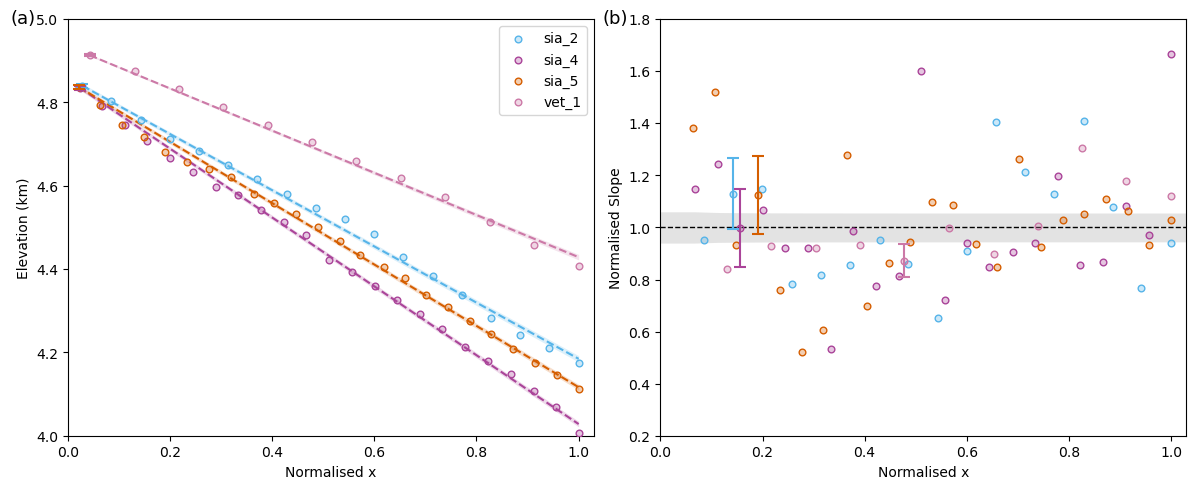

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
i_line = np.linspace(0, 1.1, 100)

# ── staggered error bar positions for panel (b) ───────────────────
ERRORBAR_IDX = {}
for i, (df, group, label, color, marker, trend) in enumerate(constant_streams):
    ERRORBAR_IDX[label] = i + 1

# ── find stream with largest mean model uncertainty for panel (b) band ──
max_band_label = None
max_band_val   = -np.inf
for df, group, label, color, marker, trend in constant_streams:
    err = error_df[error_df["Stream"] == label].reset_index(drop=True)
    b1  = df.attrs["beta'1"]
    mean_band = (err["σ_slope_model"] / b1).mean()
    if mean_band > max_band_val:
        max_band_val   = mean_band
        max_band_label = label

print(f"Panel (b) model uncertainty band plotted for: {max_band_label}")

# ==========================================================
# (a) Elevation profiles with uncertainty
# ==========================================================
for df, group, label, color, marker, trend in constant_streams:
    ss  = df.attrs["seg_stats"]
    x   = ss["Distance"].to_numpy()
    z   = ss["elevation"].to_numpy().copy()
    zp  = np.array(df.attrs["z_pred"], copy=True)

    if label == "vet_1":
        z  += 4100
        zp += 4100

    x_max = x.max()
    xn    = x / x_max

    err = error_df[error_df["Stream"] == label].reset_index(drop=True)

    ax[0].scatter(xn, z * 0.001, ec=color, fc=fc(color),
                  s=23, label=label, zorder=3)
    ax[0].plot(xn[:len(zp)], zp * 0.001,
               color=color, ls="--", zorder=2)

    ax[0].errorbar(xn[0], z[0] * 0.001,
                   yerr=err["σ_elev (m)"].iloc[0] * 0.001,
                   fmt="none", ecolor=color, elinewidth=1.5,
                   capsize=4, capthick=1.5, zorder=5)

    sigma_z = err["σ_elev_model (m)"].values[:len(zp)] * 0.001
    ax[0].fill_between(xn[:len(zp)],
                        zp * 0.001 - sigma_z,
                        zp * 0.001 + sigma_z,
                        color=color, alpha=0.20, linewidth=0)

ax[0].set(xlabel="Normalised x", ylabel="Elevation (km)",
          xlim=(0.00, 1.03), ylim=(4.0, 5.0))
ax[0].legend()
ax[0].text(-0.11, 0.99, "(a)", fontsize=13, transform=ax[0].transAxes)

# ==========================================================
# (b) Normalized slope with uncertainty
# ==========================================================
ax[1].plot(i_line, np.ones_like(i_line), "k--", lw=1)

for df, group, label, color, marker, trend in constant_streams:
    ss_full = df.attrs["seg_stats"].copy()
    x_max   = ss_full["Distance"].max()
    err_all = error_df[error_df["Stream"] == label].reset_index(drop=True)

    valid = ss_full["slope_l"].notna()
    ss    = ss_full.loc[valid].reset_index(drop=True)
    err   = err_all.loc[valid.values].reset_index(drop=True)

    if len(ss) == 0:
        continue

    x  = ss["Distance"].to_numpy()
    sl = ss["slope_l"].to_numpy()
    xn = x / x_max

    b1 = df.attrs["beta'1"]

    ax[1].scatter(xn, sl / b1, ec=color, fc=fc(color),
                  s=23, label=label, zorder=3)

    # ── staggered error bar ───────────────────────────────────
    eb_idx = min(ERRORBAR_IDX[label], len(xn) - 1)
    ax[1].errorbar(xn[eb_idx], sl[eb_idx] / b1,
                   yerr=err["σ_slope_l"].iloc[eb_idx] / b1,
                   fmt="none", ecolor=color, elinewidth=1.5,
                   capsize=4, capthick=1.5, zorder=5)

    # ── model uncertainty band — largest uncertainty stream only, varying across x ──
    if label == max_band_label:
        order        = np.argsort(xn)
        xn_sorted    = xn[order]
        band_sorted  = (err["σ_slope_model"].to_numpy() / b1)[order]

        # interpolate band onto a fixed grid spanning the full axis,
        # holding the edge values constant beyond the data range
        xn_grid   = np.linspace(0, 1.03, 200)
        band_grid = np.interp(xn_grid, xn_sorted, band_sorted)

        ax[1].fill_between(xn_grid,
                            1 - band_grid,
                            1 + band_grid,
                            color="#BBBBBB", alpha=0.40, linewidth=0,
                            label=f"Model unc. ({label})")

ax[1].set(xlabel="Normalised x", ylabel="Normalised Slope",
          xlim=(0.00, 1.03), ylim=(0.2, 1.8))
ax[1].text(-0.11, 0.99, "(b)", fontsize=13, transform=ax[1].transAxes)

# ==========================================================
# Formatting
# ==========================================================
for a in ax:
    a.tick_params(direction="out")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "Fig2_ab.pdf", dpi=600, bbox_inches="tight")
plt.show()

## Fig. 3 ab — α = 2: normalized slope & elevation

Panel (b) model uncertainty band plotted for: fou_4


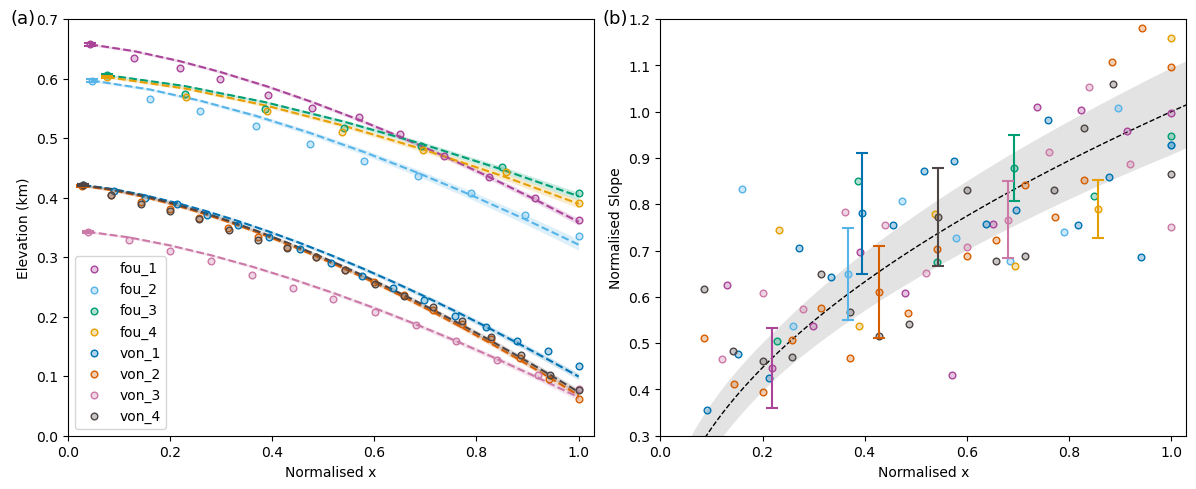

In [6]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
i_line = np.linspace(0, 1.1, 100)
ax[1].plot(i_line, i_line**0.5, "k--", lw=1)

# ── staggered error bar positions for panel (b) only ─────────────────
ERRORBAR_IDX = {}
for i, (df, group, label, color, marker, trend) in enumerate(upward_streams):
    ERRORBAR_IDX[label] = i + 1

# ── find stream with largest mean model uncertainty for panel (b) band ──
max_band_label = None
max_band_val   = -np.inf
for df, group, label, color, marker, trend in upward_streams:
    err       = error_df[error_df["Stream"] == label].reset_index(drop=True)
    b1        = df.attrs["beta'1"]
    x_max     = df.attrs["seg_stats"]["Distance"].max()
    mean_band = (err["σ_slope_model"] / (b1 * x_max**0.5)).mean()
    if mean_band > max_band_val:
        max_band_val   = mean_band
        max_band_label = label

print(f"Panel (b) model uncertainty band plotted for: {max_band_label}")

for df, group, label, color, marker, trend in upward_streams:
    err = error_df[error_df["Stream"] == label].reset_index(drop=True)

    # ==========================================================
    # Panel (a): Elevation — all streams get band + first point error bar
    # ==========================================================
    ss_all = df.attrs["seg_stats"]
    xa     = ss_all["Distance"].values
    z      = ss_all["elevation"].values.copy()
    zp     = df.attrs["z_pred"].copy()

    if label == "vet_1":
        z  += 4100
        zp += 4100

    xa_max = xa.max()
    xn_all = xa / xa_max

    ax[0].scatter(xn_all, z * 0.001, ec=color, fc=fc(color),
                  s=23, label=label, zorder=3)
    ax[0].plot(xn_all[:len(zp)], zp[:len(xa)] * 0.001,
               color=color, ls="--", zorder=2)

    # ── error bar at first valid point ────────────────────────
    ax[0].errorbar(xn_all[0], z[0] * 0.001,
                   yerr=err["σ_elev (m)"].iloc[0] * 0.001,
                   fmt="none", ecolor=color, elinewidth=1.5,
                   capsize=4, capthick=1.5, zorder=5)

    # ── model elevation uncertainty band — ALL streams ────────
    sigma_z = err["σ_elev_model (m)"].values[:len(zp)] * 0.001
    ax[0].fill_between(xn_all[:len(zp)],
                        zp * 0.001 - sigma_z,
                        zp * 0.001 + sigma_z,
                        color=color, alpha=0.20, linewidth=0)

    # ==========================================================
    # Panel (b): Normalized slope — staggered error bar + one band
    # ==========================================================
    ss        = df.attrs["seg_stats"].copy()
    valid     = ss["slope_l"].notna()
    ss_slope  = ss.loc[valid].reset_index(drop=True)
    err_slope = err.loc[valid.values].reset_index(drop=True)

    x   = ss_slope["Distance"].values
    sl  = ss_slope["slope_l"].values
    b1  = df.attrs["beta'1"]

    x_max = x.max()
    xn    = x / x_max
    y     = sl / (b1 * x_max**0.5)

    ax[1].scatter(xn, y, ec=color, fc=fc(color),
                  s=23, label=label, zorder=3)

    # ── staggered error bar ───────────────────────────────────
    eb_idx = min(ERRORBAR_IDX[label], len(xn) - 1)
    ax[1].errorbar(xn[eb_idx], y[eb_idx],
                   yerr=err_slope["σ_slope_l"].iloc[eb_idx] / (b1 * x_max**0.5),
                   fmt="none", ecolor=color, elinewidth=1.5,
                   capsize=4, capthick=1.5, zorder=5)

    if label == max_band_label:
        order        = np.argsort(xn)
        xn_sorted    = xn[order]
        band_sorted  = (err_slope["σ_slope_model"].to_numpy() / (b1 * x_max**0.5))[order]

        xn_grid    = np.linspace(0, 1.03, 200)
        band_grid  = np.interp(xn_grid, xn_sorted, band_sorted)
        model_grid = xn_grid**0.5

        ax[1].fill_between(xn_grid,
                            model_grid - band_grid,
                            model_grid + band_grid,
                            color="#BBBBBB", alpha=0.40, linewidth=0,
                            label=f"Model unc. ({label})")

# ==========================================================
# Cosmetics
# ==========================================================
ax[1].set(xlabel="Normalised x", ylabel="Normalised Slope",
          xlim=(0.0, 1.03), ylim=(0.3, 1.2))
ax[1].text(-0.11, 0.99, "(b)", fontsize=13, transform=ax[1].transAxes)

ax[0].set(xlabel="Normalised x", ylabel="Elevation (km)",
          xlim=(0.0, 1.03), ylim=(0, 0.7))
ax[0].text(-0.11, 0.99, "(a)", fontsize=13, transform=ax[0].transAxes)
ax[0].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "Fig3_ab.pdf", dpi=600, bbox_inches="tight")
plt.show()

## Fig. 3 cd — α = 0: normalized slope & elevation

Panel (d) model uncertainty band plotted for: sia_1


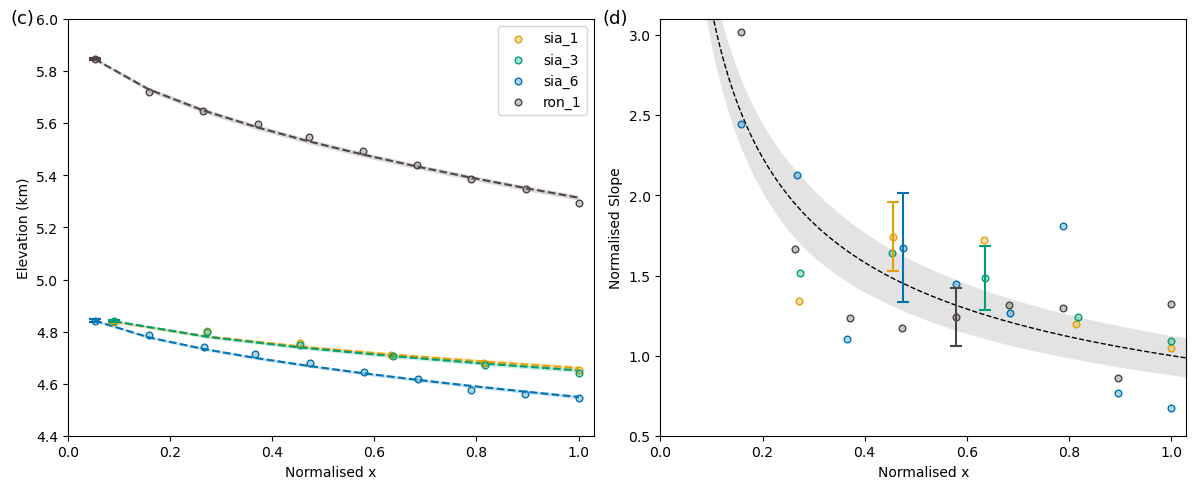

In [7]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ── single black reference line drawn once ────────────────────────────
xn_line = np.linspace(0.01, 1.03, 200)
ax[1].plot(xn_line, xn_line**-0.5, "k--", lw=1)

# ── staggered error bar positions for panel (d) only ──────────────────
ERRORBAR_IDX = {}
for i, (df, group, label, color, marker, trend) in enumerate(downward_streams):
    ERRORBAR_IDX[label] = i + 1

# ── find stream with largest mean model uncertainty for panel (d) band ──
max_band_label = None
max_band_val   = -np.inf
for df, group, label, color, marker, trend in downward_streams:
    err       = error_df[error_df["Stream"] == label].reset_index(drop=True)
    b1        = df.attrs["beta'1"]
    x_max     = df.attrs["seg_stats"]["Distance"].max()
    mean_band = (err["σ_slope_model"] / (b1 * x_max**-0.5)).mean()
    if mean_band > max_band_val:
        max_band_val   = mean_band
        max_band_label = label

print(f"Panel (d) model uncertainty band plotted for: {max_band_label}")

for df, group, label, color, marker, trend in downward_streams:
    err = error_df[error_df["Stream"] == label].reset_index(drop=True)

    # ==========================================================
    # (d) Normalized slope
    # ==========================================================
    ss        = df.attrs["seg_stats"].copy()
    valid     = ss["slope_l"].notna()
    ss_slope  = ss.loc[valid].reset_index(drop=True)
    err_slope = err.loc[valid.values].reset_index(drop=True)

    x   = ss_slope["Distance"].values
    sl  = ss_slope["slope_l"].values
    b1  = df.attrs["beta'1"]

    x_max = x.max()
    xn    = x / x_max
    y     = sl / (b1 * x_max**-0.5)

    ax[1].scatter(xn, y, ec=color, fc=fc(color),
                  s=23, label=label, zorder=3)

    # ── staggered error bar ───────────────────────────────────
    eb_idx = min(ERRORBAR_IDX[label], len(xn) - 1)
    ax[1].errorbar(xn[eb_idx], y[eb_idx],
                   yerr=err_slope["σ_slope_l"].iloc[eb_idx] / (b1 * x_max**-0.5),
                   fmt="none", ecolor=color, elinewidth=1.5,
                   capsize=4, capthick=1.5, zorder=5)

    if label == max_band_label:
        order        = np.argsort(xn)
        xn_sorted    = xn[order]
        band_sorted  = (err_slope["σ_slope_model"].to_numpy() / (b1 * x_max**-0.5))[order]

        xn_grid    = np.linspace(0.01, 1.03, 200)
        band_grid  = np.interp(xn_grid, xn_sorted, band_sorted)
        model_grid = xn_grid**-0.5

        ax[1].fill_between(xn_grid,
                            model_grid - band_grid,
                            model_grid + band_grid,
                            color="#BBBBBB", alpha=0.40, linewidth=0, zorder=1,
                            label=f"Model unc. ({label})")

    # ==========================================================
    # (c) Elevation profile
    # ==========================================================
    ss_all = df.attrs["seg_stats"]
    xa     = ss_all["Distance"].values
    z      = ss_all["elevation"].values.copy()
    zp     = df.attrs["z_pred"].copy()

    xa_max = xa.max()
    xn_all = xa / xa_max

    ax[0].scatter(xn_all, z * 0.001,
                  ec=color, fc=fc(color), s=23,
                  label=label, zorder=3)

    ax[0].plot(xn_all[:len(zp)], zp[:len(xa)] * 0.001,
               color=color, ls="--", zorder=2)

    # first-point elevation error bar
    ax[0].errorbar(xn_all[0], z[0] * 0.001,
                   yerr=err["σ_elev (m)"].iloc[0] * 0.001,
                   fmt="none", ecolor=color, elinewidth=1.5,
                   capsize=4, capthick=1.5, zorder=5)

    # model uncertainty band — all streams
    sigma_z = err["σ_elev_model (m)"].values[:len(zp)] * 0.001
    ax[0].fill_between(xn_all[:len(zp)],
                        zp * 0.001 - sigma_z,
                        zp * 0.001 + sigma_z,
                        color=color, alpha=0.20, linewidth=0, zorder=1)

# ==========================================================
# Cosmetics
# ==========================================================
ax[1].set(xlabel="Normalised x", ylabel="Normalised Slope",
          xlim=(0.0, 1.03), ylim=(0.5, 3.1))
ax[1].text(-0.11, 0.99, "(d)", fontsize=13, transform=ax[1].transAxes)

ax[0].set(xlabel="Normalised x", ylabel="Elevation (km)",
          xlim=(0.0, 1.03), ylim=(4.4, 6.0))
ax[0].text(-0.11, 0.99, "(c)", fontsize=13, transform=ax[0].transAxes)
ax[0].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "Fig3_cd.pdf", dpi=600, bbox_inches="tight")
plt.show()

## Fig.4 - Predicted v/s Observed Sinuosity

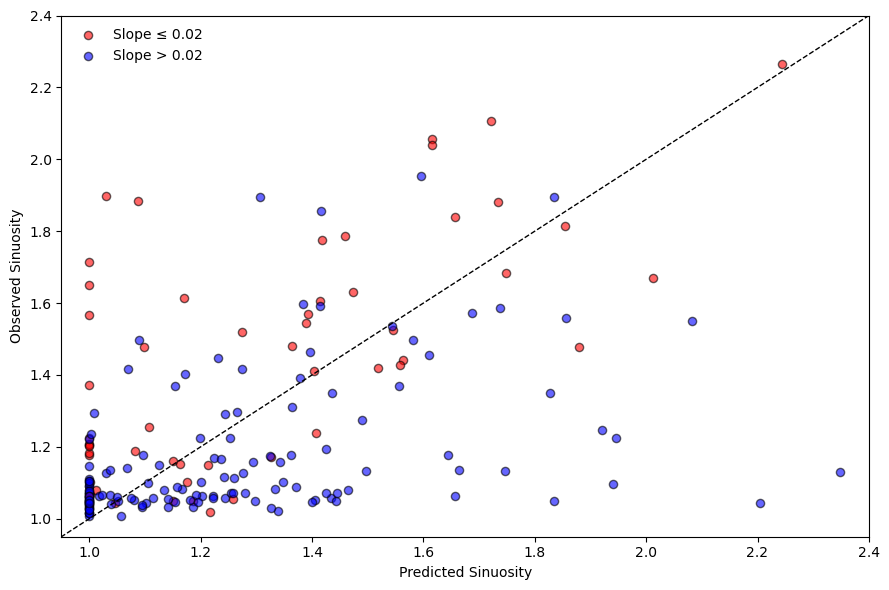

All segments
N      : 195
r      : 0.4931
R²     : 0.2431
RMSE   : 0.2979
p-value: 2.418e-13
Slope ≤ 0.02
N      : 59
r      : 0.6701
R²     : 0.4491
RMSE   : 0.2895
p-value: 6.430e-09
Slope > 0.02
N      : 136
r      : 0.4753
R²     : 0.2259
RMSE   : 0.3015
p-value: 5.005e-09

Stream-wise statistics
         N       r     R²   RMSE  p-value
Stream                                   
sia_1    5  0.0304 0.0009 0.1985   0.9612
sia_2   17  0.5026 0.2526 0.2527   0.0398
sia_3    5  0.4965 0.2465 0.1188   0.3949
sia_4   22  0.5843 0.3414 0.3722   0.0043
sia_5   23  0.3036 0.0922 0.3873   0.1591
sia_6    9 -0.1457 0.0212 0.3931   0.7085
ron_1    9  0.2320 0.0538 0.3101   0.5481
fou_1   11  0.1326 0.0176 0.2801   0.6976
fou_2    9 -0.0393 0.0015 0.4411   0.9200
fou_3    6 -0.2142 0.0459 0.1707   0.6836
fou_4    6  0.2244 0.0504 0.2521   0.6690
von_1   16  0.2038 0.0415 0.2425   0.4491
von_2   17  0.4794 0.2298 0.2111   0.0515
von_3   12 -0.0051 0.0000 0.2080   0.9874
von_4   17  0.0463 0.0021 

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from sklearn.metrics import mean_squared_error

# ==========================================================
# Stream selection
# ==========================================================
SELECTED_STREAMS = [
    "sia_1","sia_2","sia_3","sia_4","sia_5","sia_6",
    "ron_1",
    "fou_1","fou_2","fou_3","fou_4",
    "von_1","von_2","von_3","von_4",
    "vet_1",
]

SLOPE_THRESHOLD = 0.020
selected = [e for e in stream_registry if e[2] in SELECTED_STREAMS]

# ==========================================================
# Figure
# ==========================================================
fig, ax = plt.subplots(figsize=(9,6))
line = np.linspace(0.8, 3.1, 100)
ax.plot(line, line, 'k--', lw=1)

# ==========================================================
# Containers
# ==========================================================
all_obs, all_pred = [], []
low_obs, low_pred = [], []
high_obs, high_pred = [], []
stream_data = {}   # per-stream obs/pred for stream-wise stats

# ==========================================================
# Loop over streams
# ==========================================================
for df, group, label, color, marker, trend in selected:
    ss = df.attrs["seg_stats"]

    obs, pred, slope = ss["sinuosity"].values, np.maximum(df.attrs["sin_pred"], 1), ss["slope_l"].values
    n = min(len(obs), len(pred), len(slope))
    obs, pred, slope = obs[:n], pred[:n], slope[:n]

    mask = np.isfinite(obs) & np.isfinite(pred) & np.isfinite(slope)
    obs, pred, slope = obs[mask], pred[mask], slope[mask]

    # ---------- store for stream-wise stats ----------
    stream_data[label] = (obs, pred)

    # ---------- All ----------
    all_obs.extend(obs); all_pred.extend(pred)

    # ---------- Low slope ----------
    mask_low = slope <= SLOPE_THRESHOLD
    if np.any(mask_low):
        ax.scatter(pred[mask_low], obs[mask_low], c="red", edgecolor="k", s=35, alpha=0.6,
                   label="Slope ≤ 0.02" if len(low_obs) == 0 else "")
        low_obs.extend(obs[mask_low]); low_pred.extend(pred[mask_low])

    # ---------- High slope ----------
    mask_high = slope > SLOPE_THRESHOLD
    if np.any(mask_high):
        ax.scatter(pred[mask_high], obs[mask_high], c="blue", edgecolor="k", s=35, alpha=0.6,
                   label="Slope > 0.02" if len(high_obs) == 0 else "")
        high_obs.extend(obs[mask_high]); high_pred.extend(pred[mask_high])

# ==========================================================
# Plot formatting
# ==========================================================
ax.set_xlabel("Predicted Sinuosity"); ax.set_ylabel("Observed Sinuosity")
ax.set_xlim(0.95, 2.4); ax.set_ylim(0.95, 2.4)
ax.legend(frameon=False)
ax.tick_params(direction='out')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "Fig4.pdf", dpi=600, bbox_inches="tight")
plt.show()

# ==========================================================
# Statistics function
# ==========================================================
def print_statistics(name, obs, pred):
    obs, pred = np.asarray(obs), np.asarray(pred)
    r, p = scipy_stats.pearsonr(obs, pred)
    r2, rmse = r**2, np.sqrt(mean_squared_error(obs, pred))
    print("="*55); print(name); print("="*55)
    print(f"N      : {len(obs)}")
    print(f"r      : {r:.4f}")
    print(f"R²     : {r2:.4f}")
    print(f"RMSE   : {rmse:.4f}")
    print(f"p-value: {p:.3e}")

def compute_statistics(obs, pred):
    obs, pred = np.asarray(obs), np.asarray(pred)
    r, p = scipy_stats.pearsonr(obs, pred)
    return {"N": len(obs), "r": round(r,4), "R²": round(r**2,4),
            "RMSE": round(np.sqrt(mean_squared_error(obs, pred)),4), "p-value": p}

# ==========================================================
# Print statistics — overall groups
# ==========================================================
print_statistics("All segments", all_obs, all_pred)
print_statistics(f"Slope ≤ {SLOPE_THRESHOLD}", low_obs, low_pred)
print_statistics(f"Slope > {SLOPE_THRESHOLD}", high_obs, high_pred)

# ==========================================================
# Stream-wise statistics — table
# ==========================================================
rows = []
for label, (obs, pred) in stream_data.items():
    if len(obs) >= 2:
        rows.append({"Stream": label, **compute_statistics(obs, pred)})
    else:
        rows.append({"Stream": label, "N": len(obs), "r": np.nan, "R²": np.nan, "RMSE": np.nan, "p-value": np.nan})

stats_table = pd.DataFrame(rows).set_index("Stream")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print("\n" + "="*55)
print("Stream-wise statistics")
print("="*55)
print(stats_table)
pd.reset_option("display.float_format")

## Fig. S5 — Elevation profiles per glacier group

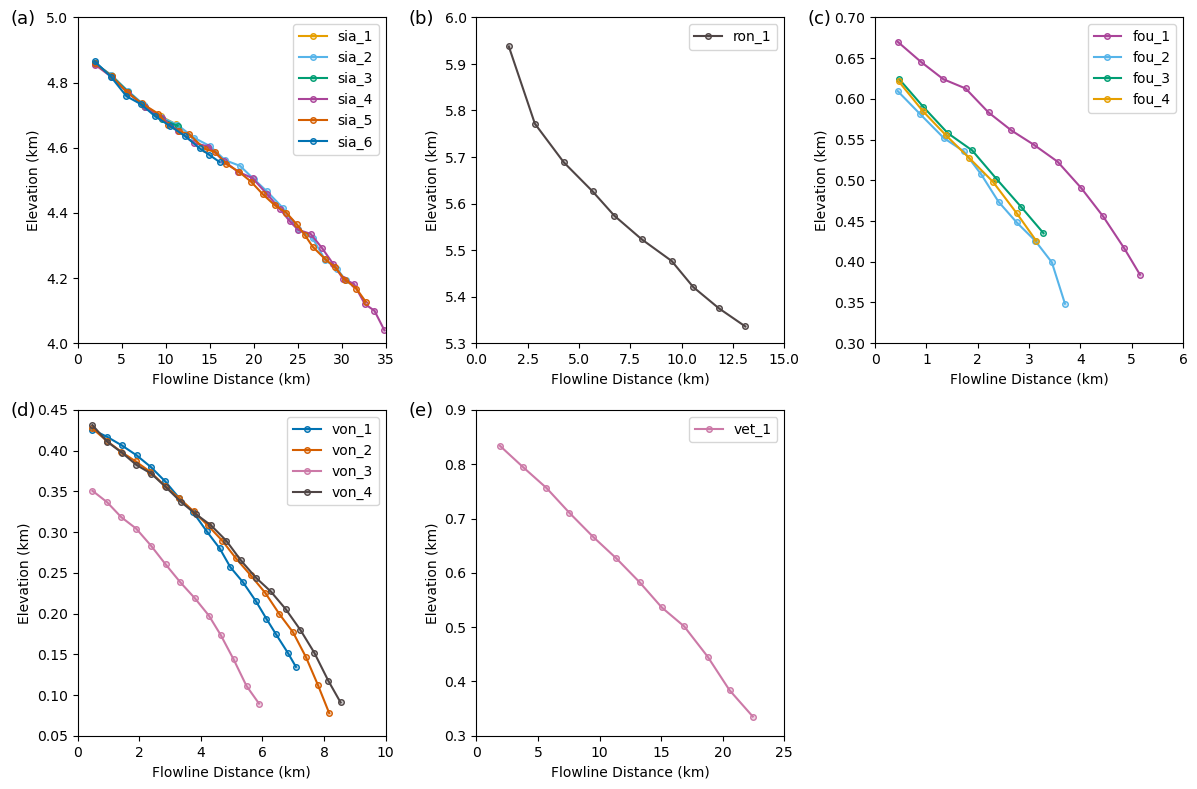

In [9]:
group_order  = ["Siachen", "Rongbuk", "Fountain", "Vonbreen", "Veteranbreen"]
xlims        = [(0,35), (0,15), (0,6), (0,10), (0,25)]
ylims        = [(4.0,5.0), (5.3,6.0), (0.30,0.70), (0.05,0.45), (0.3,0.9)]
panel_labels = list("abcde")

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
axes = ax.flatten()

for idx, group_name in enumerate(group_order):
    axi = axes[idx]
    for df, group, label, color, marker, trend in group_subsets.get(group_name, []):
        ss = df.attrs["seg_stats"]
        x  = ss["Acc_Norm"].values * 0.001
        z  = ss["elevation_max"].values * 0.001    # offset already applied in loading
        axi.plot(x[:len(z)], z[:len(x)], marker=marker, markeredgecolor=color,
                 markerfacecolor=fc(color), markersize=4, color=color, label=label)
    axi.set(xlim=xlims[idx], xlabel="Flowline Distance (km)", ylabel="Elevation (km)")
    if ylims[idx]:
        axi.set_ylim(ylims[idx])
    axi.text(-0.22, 0.98, f"({panel_labels[idx]})", fontsize=13, transform=axi.transAxes)
    axi.legend()

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "FigS5.pdf", dpi=600, bbox_inches="tight")
plt.show()


## Fig. S6 — Flux profiles per glacier group

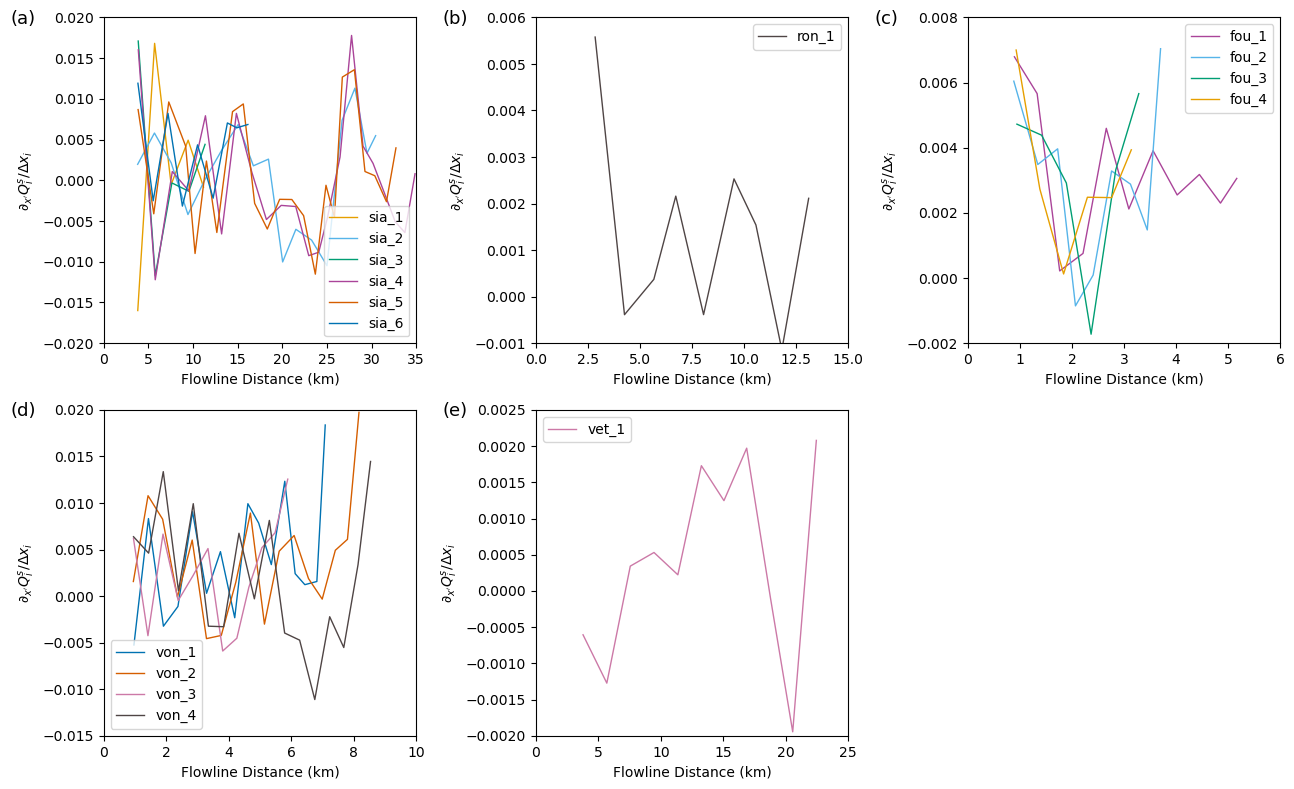

In [10]:
ylims_flux = [(-0.02,0.02), (-0.001,0.006), (-0.002,0.008), (-0.015,0.020), (-0.002,0.0025)]

fig, ax = plt.subplots(2, 3, figsize=(13, 8))
axes = ax.flatten()

for idx, group_name in enumerate(group_order):
    axi = axes[idx]
    for df, group, label, color, marker, trend in group_subsets.get(group_name, []):
        ss = df.attrs["seg_stats"]
        axi.plot(ss["Acc_Norm"] * 0.001, ss["flux_stream_len"],
                 color=color, linewidth=1, label=label)
    axi.set(ylim=ylims_flux[idx], xlim=xlims[idx], 
            xlabel="Flowline Distance (km)", ylabel=r"$\partial_{x'}Q_i^s/{\Delta x_i}$",)
    axi.text(-0.30, 0.98, f"({panel_labels[idx]})", fontsize=13, transform=axi.transAxes)
    axi.legend()

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "FigS6.pdf", dpi=600, bbox_inches="tight")
plt.show()

## Fig S7 — Sinuosity & slope KDE

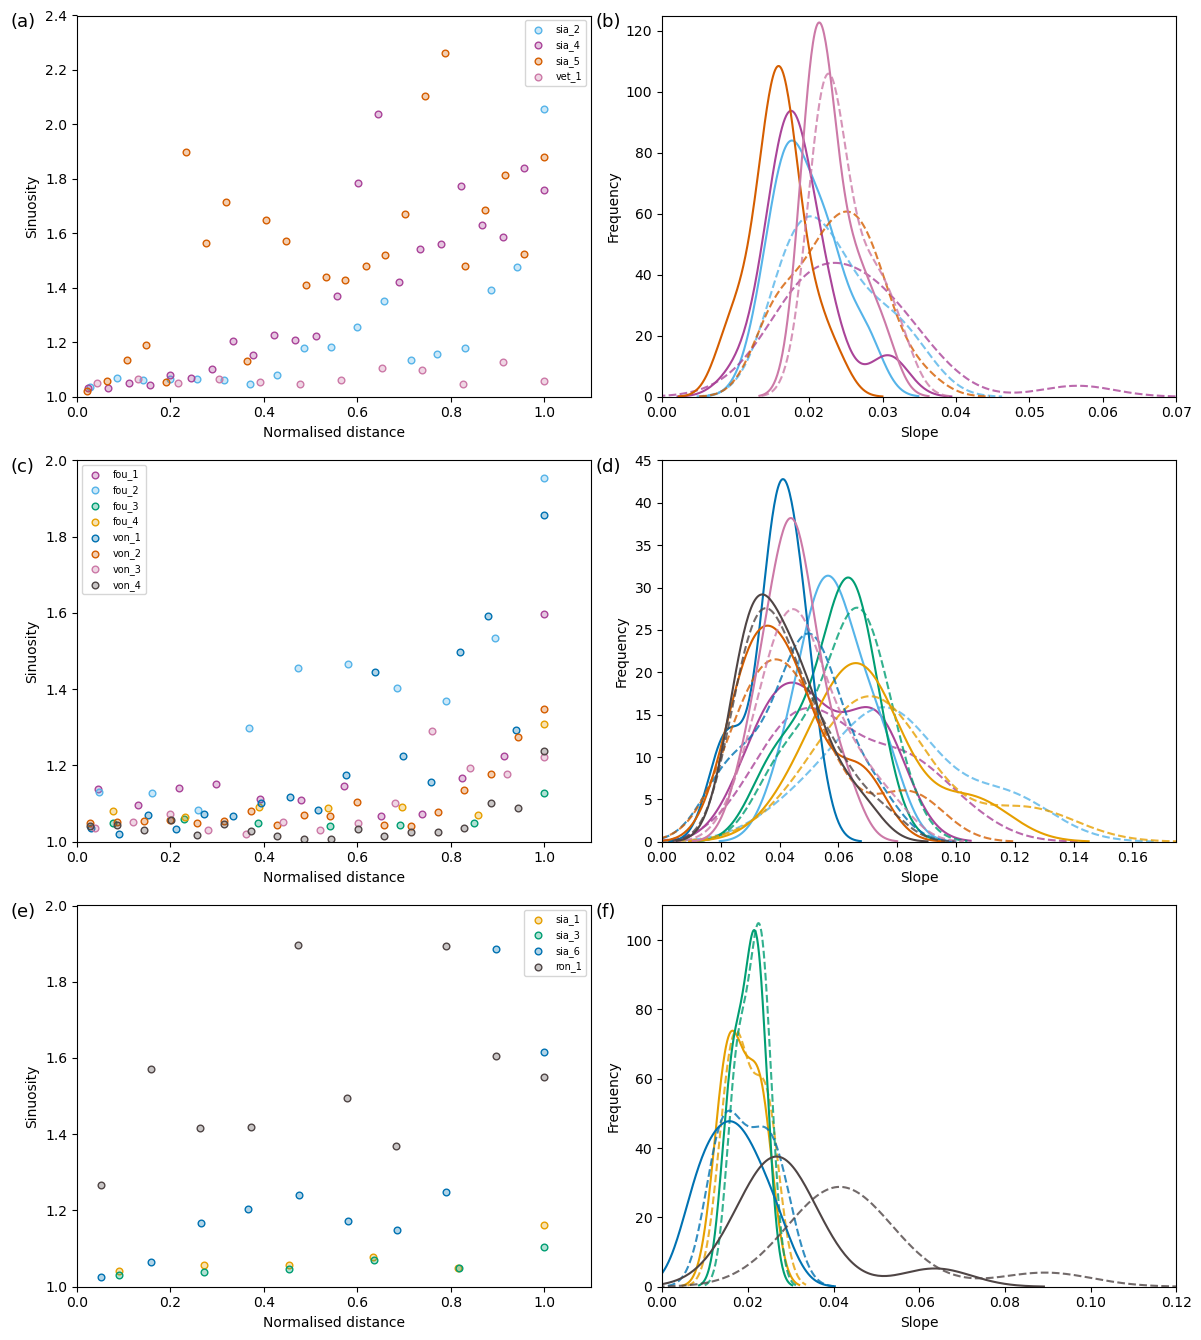

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2,figsize=(12, 13.5),gridspec_kw={"width_ratios": [1.3, 1.3]})

regime_configs = [
    (constant_streams, ("a", "b"), (0.07, 125), (1.0, 2.4)),
    (upward_streams,   ("c", "d"), (0.175, 45), (1.0, 2.0)),
    (downward_streams, ("e", "f"), (0.12, 110), (1.0, 2.0)),
]
for row_idx, (group_entries, panels,(xlim_sl, ylim_sl), (ylim_min, ylim_max)) in enumerate(regime_configs):

    ax_sin = axes[row_idx, 0]
    ax_kde = axes[row_idx, 1]

    # ------------------------------------------------------
    # Plot each stream
    # ------------------------------------------------------
    for df, group, label, color, marker, trend in group_entries:

        ss = df.attrs["seg_stats"]
        x_norm = ss["Distance"] / ss["Distance"].max()

        # Sinuosity
        ax_sin.scatter(x_norm,ss["sinuosity"],ec=color,fc=fc(color),marker=marker,s=23,label=label)

        # Longitudinal slope KDE
        sns.kdeplot(ss["slope_l"],color=color,linestyle="-",ax=ax_kde,common_norm=False)

        # Down-valley slope KDE
        sns.kdeplot(ss["slope_d"],color=color,linestyle="--",ax=ax_kde,common_norm=False,alpha=0.8)

    # ------------------------------------------------------
    # Formatting
    # ------------------------------------------------------
    ax_sin.set_xlim(0, 1.1)
    ax_sin.set_ylim(ylim_min, ylim_max)
    ax_sin.set_xlabel("Normalised distance")
    ax_sin.set_ylabel("Sinuosity")
    ax_sin.text(-0.13, 0.97,f"({panels[0]})",transform=ax_sin.transAxes,fontsize=13)
    ax_sin.legend(fontsize=7)

    ax_kde.set_xlim(0, xlim_sl)
    ax_kde.set_ylim(0, ylim_sl)
    ax_kde.set_xlabel("Slope")
    ax_kde.set_ylabel("Frequency")
    ax_kde.text(-0.13, 0.97,f"({panels[1]})",transform=ax_kde.transAxes,fontsize=13)

    ax_sin.tick_params(direction="out")
    ax_kde.tick_params(direction="out")

# ==========================================================
# Save figure
# ==========================================================
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "FigS7.pdf",dpi=600,bbox_inches="tight")
plt.show()

## Mean (IQR) slope, sinuosty

In [12]:
# ── select any streams by their label code ───────────────────────────
selected_labels = ["sia_1", "sia_2"]   # ← change as needed

all_rows = []

for entry in stream_registry:
    df, group, label, color, marker, trend = entry

    if label not in selected_labels:
        continue

    ss       = df.attrs["seg_stats"]
    sin_obs  = ss["sinuosity"].values
    sin_pred = df.attrs["sin_pred"]
    n        = min(len(sin_obs), len(sin_pred))

    obs  = sin_obs[:n]
    pred = sin_pred[:n]

    for seg_idx, (o, p) in enumerate(zip(obs, pred)):
        all_rows.append({
            "Stream":    label,
            "Group":     group,
            "Trend":     trend,
            "Segment":   seg_idx + 1,
            "Obs Sin":   round(o,   4),
            "Pred Sin":  round(p,   4) if np.isfinite(p) else np.nan,
            "Residual":  round(o-p, 4) if np.isfinite(p) else np.nan,
        })

result_df = pd.DataFrame(all_rows)

# display full table
pd.set_option("display.max_rows",    None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width",       10000)
print(result_df.to_string(index=False))

# optional: save to CSV
result_df.to_csv(OUTPUT_DIR + "obs_pred_sinuosity.csv", index=False)

Stream   Group      Trend  Segment  Obs Sin  Pred Sin  Residual
 sia_1 Siachen decreasing        1   1.0410       NaN       NaN
 sia_1 Siachen decreasing        2   1.0572    0.7314    0.3258
 sia_1 Siachen decreasing        3   1.0583    1.2429   -0.1847
 sia_1 Siachen decreasing        4   1.0790    1.4653   -0.3863
 sia_1 Siachen decreasing        5   1.0480    1.1495   -0.1015
 sia_1 Siachen decreasing        6   1.1616    1.1509    0.0107
 sia_2 Siachen   constant        1   1.0361       NaN       NaN
 sia_2 Siachen   constant        2   1.0677    1.0010    0.0667
 sia_2 Siachen   constant        3   1.0627    1.2031   -0.1405
 sia_2 Siachen   constant        4   1.0633    1.2217   -0.1584
 sia_2 Siachen   constant        5   1.0645    0.8328    0.2317
 sia_2 Siachen   constant        6   1.0616    0.8673    0.1943
 sia_2 Siachen   constant        7   1.0460    0.9033    0.1427
 sia_2 Siachen   constant        8   1.0810    1.0113    0.0697
 sia_2 Siachen   constant        9   1.1